In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge,LinearRegression
from sklearn.datasets import load_diabetes,make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [131]:
x=np.arange(-4,2,0.05).reshape(-1,1)
y=3*(x**3)-4.5*(x**2)+9*x-300+50*np.random.randn(120,1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
x.shape

(120, 1)

In [140]:
m1=Pipeline([('poly_feats',PolynomialFeatures(degree=20)),('ridge',Ridge(alpha=0))])
m1.fit(x_train,y_train)
y_ridge1=m1.predict(x_test)
r2_score(y_test,m1.predict(x_test))

0.6708222904371032

In [145]:
m2=Pipeline([('poly_feats',PolynomialFeatures(degree=20)),('ridge',Ridge(alpha=20))])
m2.fit(x_train,y_train)
y_ridge2=m2.predict(x_test)
r2_score(y_test,m2.predict(x_test))

C:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=7.07768e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


0.8333260527774824

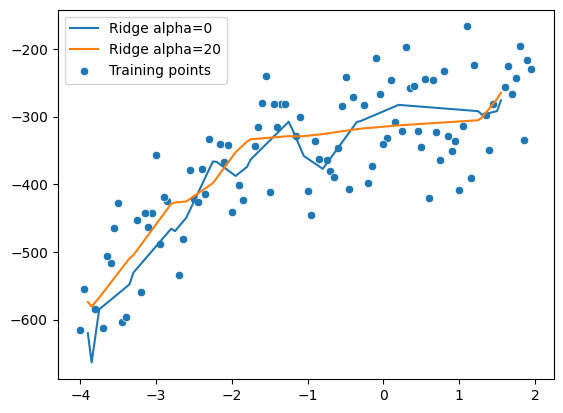

In [146]:
sns.lineplot(x=x_test.flatten(),y=y_ridge1.flatten(),label='Ridge alpha=0')
sns.lineplot(x=x_test.flatten(),y=y_ridge2.flatten(),label='Ridge alpha=20')
sns.scatterplot(x=x_train.flatten(),y=y_train.flatten(),label='Training points')
plt.legend()
plt.show()

Making OWN Ridge class

In [3]:
class ridge:
    def __init__(self,alpha=1):
        self.m=None
        self.b=None
        self.alpha=alpha
    def fit(self,x,y):
        x_mean=x.mean()
        y_mean=y.mean()
        num=0
        den=0
        for i in range(x.shape[0]):
            num=num+(y[i]-y_mean)*(x[i]-x_mean)
            den=den+(x[i]-x_mean)**2
        self.m=num/(den+self.alpha)
        self.b=y_mean-(self.m*x_mean)
        print(self.m,self.b)
    def predict(self,x):
        return self.m*x+self.b

In [11]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=2)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [32]:
m3=ridge(alpha=6)
m3.fit(x_train,y_train)
print(r2_score(y_test,m3.predict(x_test)))
ridge1=m3.predict(x_test)

[53.79335455] [-0.71618656]
0.8953489740059914


In [33]:
m4=LinearRegression()
m4.fit(x_train,y_train)
print(m4.coef_,m4.intercept_,r2_score(y_test,m4.predict(x_test)))
lr=m4.predict(x_test)

[57.25933739] -0.2009464759960533 0.9095184055289016


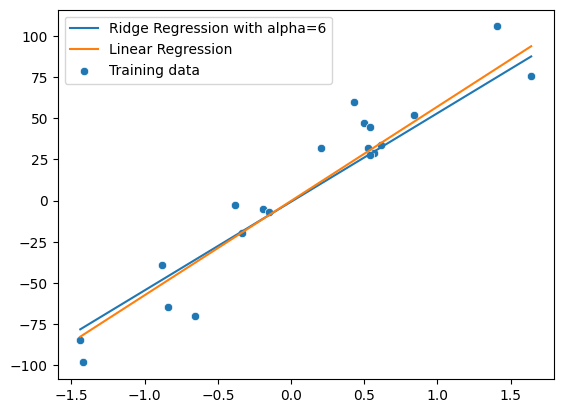

In [35]:
sns.lineplot(x=x_test.flatten(),y=ridge1.flatten(),label='Ridge Regression with alpha=6')
sns.lineplot(x=x_test.flatten(),y=lr.flatten(),label='Linear Regression')
sns.scatterplot(x=x_test.flatten(),y=y_test.flatten(),label='Training data')
plt.legend()
plt.show()